<a href="https://colab.research.google.com/github/Chekuriakhilvarma/Project_Code/blob/main/Code_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries for image dataset exploratory analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing import image
# Install packages needed
!pip install -U keras-cv split-folders
# Utility for splitting dataset folders into train/val/test sets
import splitfolders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 40.5 MB/s eta 0:00:00


In [ ]:
# Mount Google Drive and define the training directory for the indoor scene dataset

from google.colab import drive

# Mount the user's Google Drive to make dataset files accessible
drive.mount('/content/drive')

# Abbreviated path variable for the indoor scene training dataset
ind_scene_tr_dir = '/content/drive/MyDrive/Dataset/train'


Mounted at /content/drive


In [ ]:
# Split the indoor scene dataset into training and validation folders
splitfolders.ratio(
    ind_scene_tr_dir,
    output="/content/IndoorScene_Split",
    seed=24000105,
    ratio=(0.70, 0.30),
    move=False
)

# Store the path to the training split directory
ind_scene_tr_split_dir = "/content/IndoorScene_Split/train"

# Store the path to the validation split directory
ind_scene_val_split_dir = "/content/IndoorScene_Split/val"


Copying files: 2227 files [02:29, 14.94 files/s]


In [ ]:
# Define dataset directories for train, validation, and test splits
eda_tr_dir = "/content/IndoorScene_Split/train"
eda_val_dir = "/content/IndoorScene_Split/val"
eda_tst_dir = "/content/drive/MyDrive/Dataset/test"


In [ ]:
# Collect image count statistics per class for each dataset split
def get_split_stats(split_dir, split_name):
    rows = []
    for cls in sorted(os.listdir(split_dir)):
        cls_pth = os.path.join(split_dir, cls)
        if os.path.isdir(cls_pth):
            img_cnt = len([
                f for f in os.listdir(cls_pth)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            rows.append({
                "split": split_name,
                "class": cls,
                "count": img_cnt
            })
    return rows


In [ ]:
# Build a dataframe summarizing class-wise image counts
stats_rows = []
stats_rows += get_split_stats(eda_tr_dir, "train")
stats_rows += get_split_stats(eda_val_dir, "val")
stats_rows += get_split_stats(eda_tst_dir, "test")

dist_df = pd.DataFrame(stats_rows)


In [ ]:
# Display class-wise image counts in table format
display(dist_df.pivot(index="class", columns="split", values="count"))


split,test,train,val
class,,,
auditorium,167,6,3
bowling,60,107,46
buffet,27,58,26
cloister,42,54,24
deli,66,133,57
florist,24,55,24
gym,64,116,51
laundromat,33,170,73
library,13,65,29


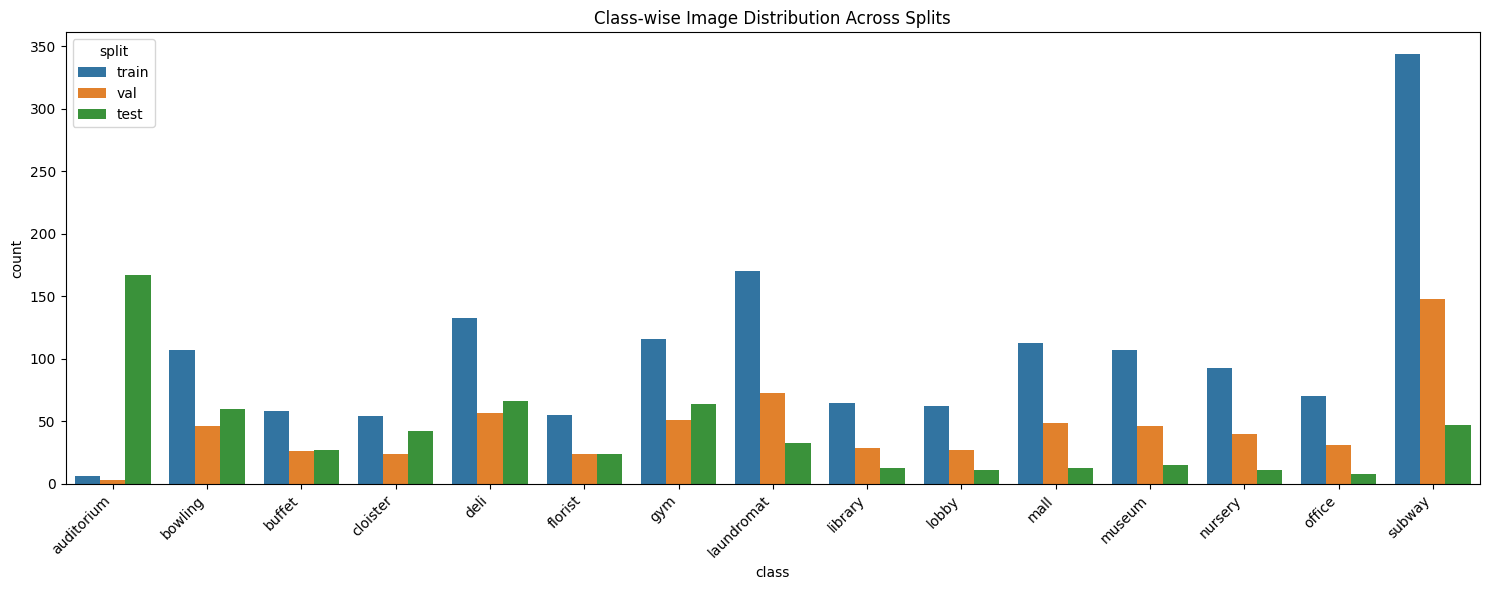

In [ ]:
# Visualize class distribution across dataset splits
plt.figure(figsize=(15, 6))
sns.barplot(
    data=dist_df,
    x="class",
    y="count",
    hue="split"
)
plt.xticks(rotation=45, ha="right")
plt.title("Class-wise Image Distribution Across Splits")
plt.tight_layout()
plt.show()


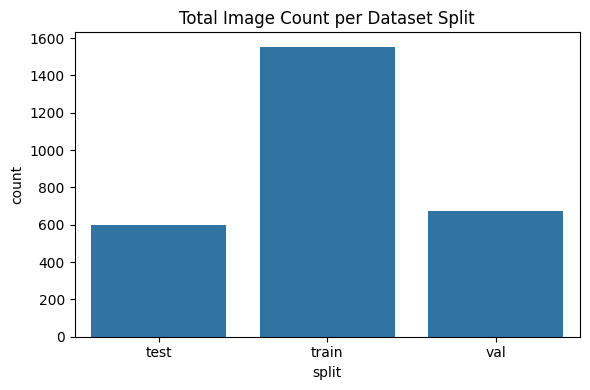

In [ ]:
# Plot total image count per dataset split
totals_df = dist_df.groupby("split", as_index=False)["count"].sum()

plt.figure(figsize=(6, 4))
sns.barplot(
    data=totals_df,
    x="split",
    y="count"
)
plt.title("Total Image Count per Dataset Split")
plt.tight_layout()
plt.show()


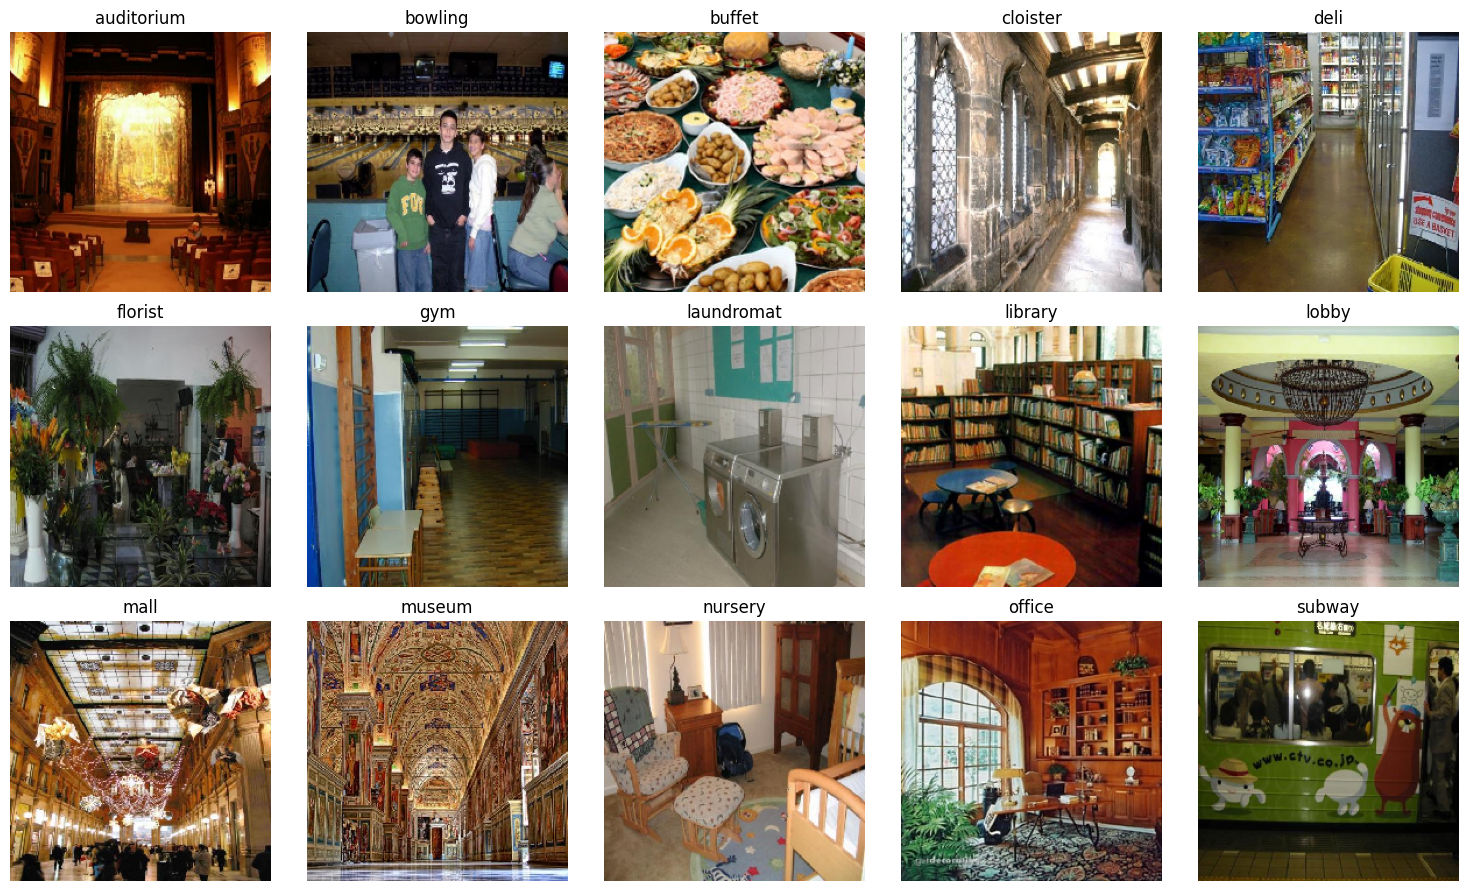

In [ ]:
# Display one sample image per class in a 3x5 grid from training set
cls_list = sorted(os.listdir(eda_tr_dir))

plt.figure(figsize=(15, 9))
for idx, cls in enumerate(cls_list[:15]):
    cls_dir = os.path.join(eda_tr_dir, cls)
    img_files = [
        f for f in os.listdir(cls_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    if len(img_files) > 0:
        img_pth = os.path.join(cls_dir, img_files[0])
        img = image.load_img(img_pth, target_size=(224, 224))
        plt.subplot(3, 5, idx + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Analyze class imbalance using max-to-min image ratio
imb_df = (
    dist_df
    .groupby("split")["count"]
    .agg(["min", "max"])
    .reset_index()
)

imb_df["imbalance_ratio"] = imb_df["max"] / imb_df["min"]

display(imb_df)


,split,min,max,imbalance_ratio
0,test,8,167,20.875000
1,train,6,344,57.333333
2,val,3,148,49.333333


In [ ]:
# Import extra utilities for deeper image EDA (sizes, corruption checks, pixel stats, augmentation preview)
from PIL import Image
import tensorflow as tf


In [ ]:
# Build a helper that lists image file paths for a split directory with optional per-class cap
def ls_img_pths(root_dir, per_cls_cap=None):
    """Return a list of image file paths under root_dir, optionally limiting files per class folder."""
    all_pths = []
    for cls in sorted(os.listdir(root_dir)):
        cls_dir = os.path.join(root_dir, cls)
        if os.path.isdir(cls_dir):
            img_fns = [
                f for f in os.listdir(cls_dir)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
            img_fns = sorted(img_fns)
            if per_cls_cap is not None:
                img_fns = img_fns[:per_cls_cap]
            for fn in img_fns:
                all_pths.append(os.path.join(cls_dir, fn))
    return all_pths


In [ ]:
# Create file lists for train, val, and test for quick sampling-based analysis
tr_pths = ls_img_pths(eda_tr_dir, per_cls_cap=200)
val_pths = ls_img_pths(eda_val_dir, per_cls_cap=200)
tst_pths = ls_img_pths(eda_tst_dir, per_cls_cap=200)


In [ ]:
# Detect corrupt or unreadable images across splits and show a summary table
def chk_bad_imgs(img_pths):
    """Return a dataframe with unreadable image paths and error messages."""
    bad_rows = []
    for pth in img_pths:
        try:
            with Image.open(pth) as im:
                im.verify()
        except Exception as e:
            bad_rows.append({"img_path": pth, "err": str(e)})
    return pd.DataFrame(bad_rows)

bad_tr_df = chk_bad_imgs(tr_pths)
bad_val_df = chk_bad_imgs(val_pths)
bad_tst_df = chk_bad_imgs(tst_pths)

bad_sum_df = pd.DataFrame([
    {"split": "train", "bad_cnt": len(bad_tr_df)},
    {"split": "val", "bad_cnt": len(bad_val_df)},
    {"split": "test", "bad_cnt": len(bad_tst_df)}
])

display(bad_sum_df)


,split,bad_cnt
0,train,0
1,val,0
2,test,0


In [ ]:
# Show a few corrupt image paths if any are detected
if len(bad_tr_df) > 0:
    display(bad_tr_df.head(10))

if len(bad_val_df) > 0:
    display(bad_val_df.head(10))

if len(bad_tst_df) > 0:
    display(bad_tst_df.head(10))


In [ ]:
# Compute resolution and aspect ratio statistics for a sample of images per split
def get_img_dims(img_pths, split_nm, cap=2000):
    """Return a dataframe with width, height, and aspect ratio for up to cap images."""
    rows = []
    use_pths = img_pths[:cap]
    for pth in use_pths:
        try:
            with Image.open(pth) as im:
                w, h = im.size
            rows.append({
                "split": split_nm,
                "w": int(w),
                "h": int(h),
                "ar": float(w) / float(h)
            })
        except Exception:
            pass
    return pd.DataFrame(rows)

dims_tr_df = get_img_dims(tr_pths, "train", cap=2000)
dims_val_df = get_img_dims(val_pths, "val", cap=2000)
dims_tst_df = get_img_dims(tst_pths, "test", cap=2000)

dims_df = pd.concat([dims_tr_df, dims_val_df, dims_tst_df], ignore_index=True)
display(dims_df.describe(include="all"))


,split,w,h,ar
count,2684,2684.0,2684.0,2684.0
unique,3,NaN,NaN,NaN
top,train,NaN,NaN,NaN
freq,1409,NaN,NaN,NaN
mean,NaN,416.0,416.0,1.0
std,NaN,0.0,0.0,0.0
min,NaN,416.0,416.0,1.0
25%,NaN,416.0,416.0,1.0
50%,NaN,416.0,416.0,1.0
75%,NaN,416.0,416.0,1.0


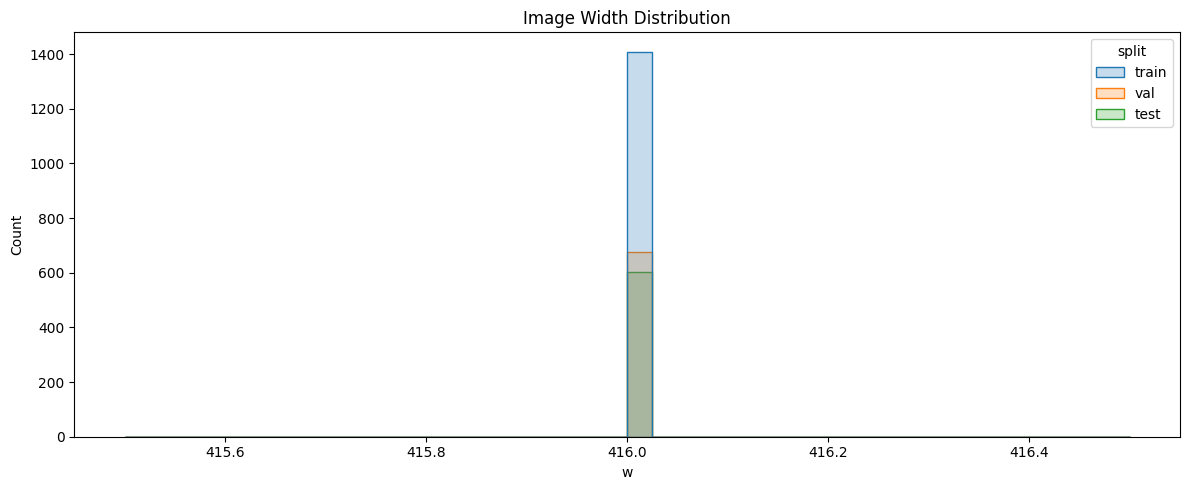

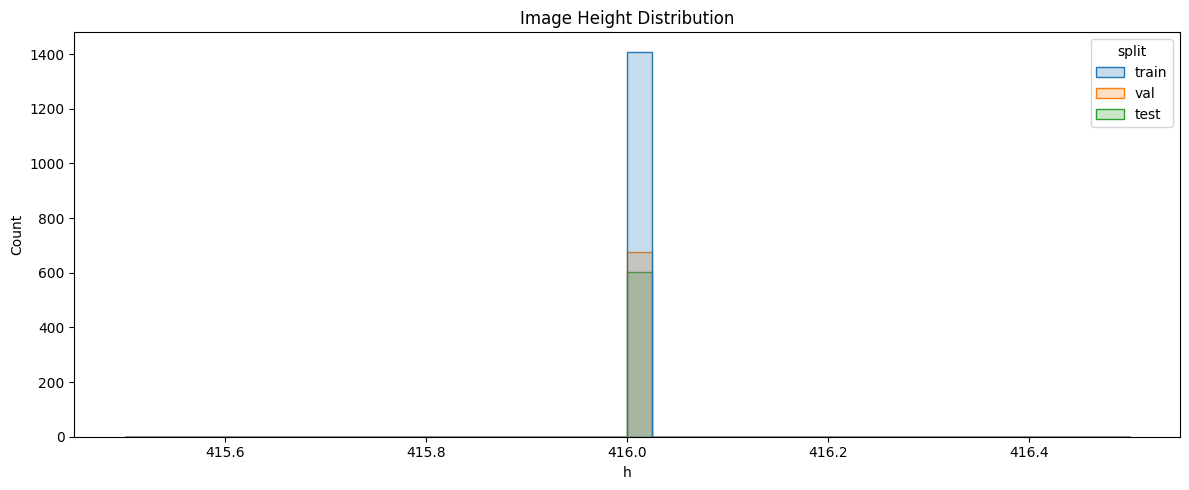

In [ ]:
# Plot width and height distributions for train, val, and test
plt.figure(figsize=(12, 5))
sns.histplot(data=dims_df, x="w", hue="split", bins=40, element="step")
plt.title("Image Width Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(data=dims_df, x="h", hue="split", bins=40, element="step")
plt.title("Image Height Distribution")
plt.tight_layout()
plt.show()


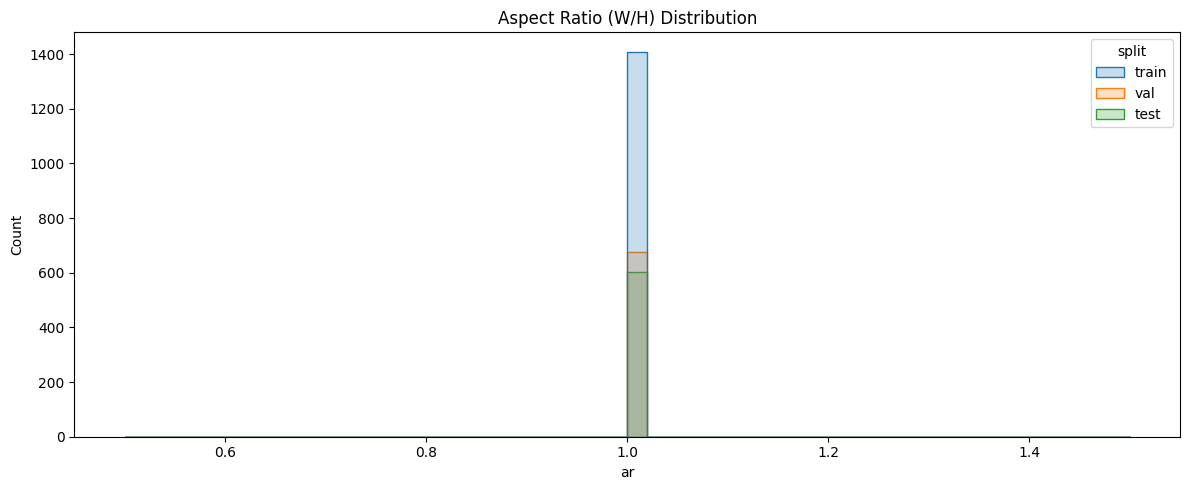

In [ ]:
# Plot aspect ratio distribution to spot unusual shapes or cropping issues
plt.figure(figsize=(12, 5))
sns.histplot(data=dims_df, x="ar", hue="split", bins=50, element="step")
plt.title("Aspect Ratio (W/H) Distribution")
plt.tight_layout()
plt.show()


In [ ]:
# Compute brightness and contrast statistics using grayscale pixel summaries
def get_gray_stats(img_pths, split_nm, cap=1500, tgt_sz=(224, 224)):
    """Return per-image grayscale mean and std as brightness and contrast proxies."""
    rows = []
    use_pths = img_pths[:cap]
    for pth in use_pths:
        try:
            with Image.open(pth) as im:
                im = im.convert("RGB")
                im = im.resize(tgt_sz)
                arr = np.asarray(im).astype("float32")
            gray = (0.299 * arr[:, :, 0]) + (0.587 * arr[:, :, 1]) + (0.114 * arr[:, :, 2])
            rows.append({
                "split": split_nm,
                "gray_mean": float(np.mean(gray)),
                "gray_std": float(np.std(gray))
            })
        except Exception:
            pass
    return pd.DataFrame(rows)

gs_tr_df = get_gray_stats(tr_pths, "train", cap=1500)
gs_val_df = get_gray_stats(val_pths, "val", cap=1500)
gs_tst_df = get_gray_stats(tst_pths, "test", cap=1500)

gs_df = pd.concat([gs_tr_df, gs_val_df, gs_tst_df], ignore_index=True)
display(gs_df.groupby("split")[["gray_mean", "gray_std"]].describe())


gray_mean                                                           \
          count        mean        std        min        25%         50%   
split                                                                      
test      601.0  105.115324  27.511645  23.273052  87.176590  106.792183   
train    1409.0  112.234829  27.490068  28.355330  95.131958  111.623352   
val       674.0  109.272362  27.250996  27.872776  91.625471  109.095383   

                              gray_std                                   \
              75%         max    count       mean        std        min   
split                                                                     
test   122.527367  204.429474    601.0  56.107131  11.124261  18.185587   
train  129.201279  209.671692   1409.0  55.408686  11.072611  15.651892   
val    126.911150  199.138031    674.0  56.419522  11.145371  15.040966   

                                                   
             25%        50%        75%        max  
split                                              
test   48.301308  56.059174  63.307442  91.306038  
train  48.300129  55.315472  62.731392  97.753365  
val    49.345404  56.097170  63.727355  95.548782

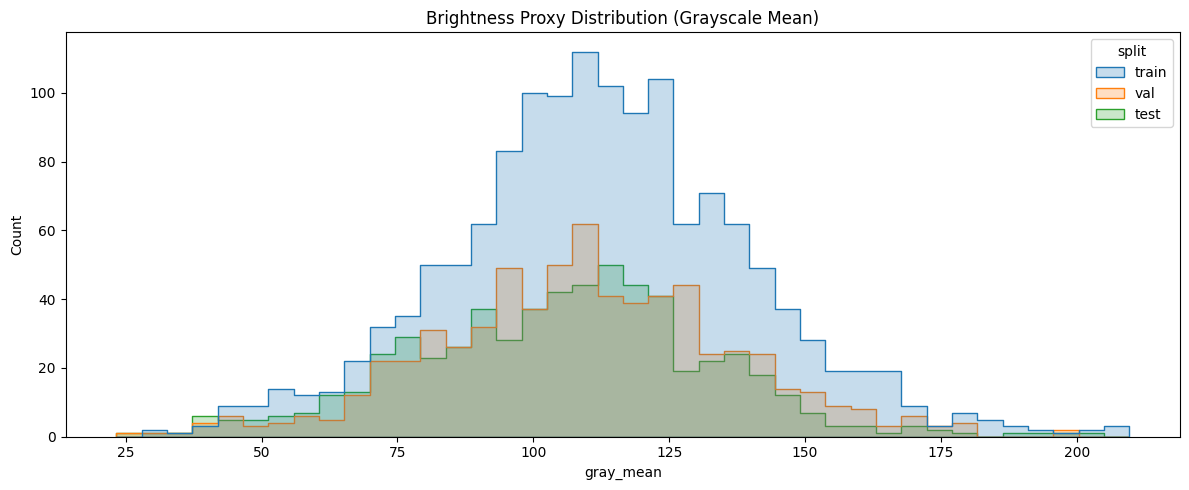

In [ ]:
# Plot brightness distribution across splits
plt.figure(figsize=(12, 5))
sns.histplot(data=gs_df, x="gray_mean", hue="split", bins=40, element="step")
plt.title("Brightness Proxy Distribution (Grayscale Mean)")
plt.tight_layout()
plt.show()


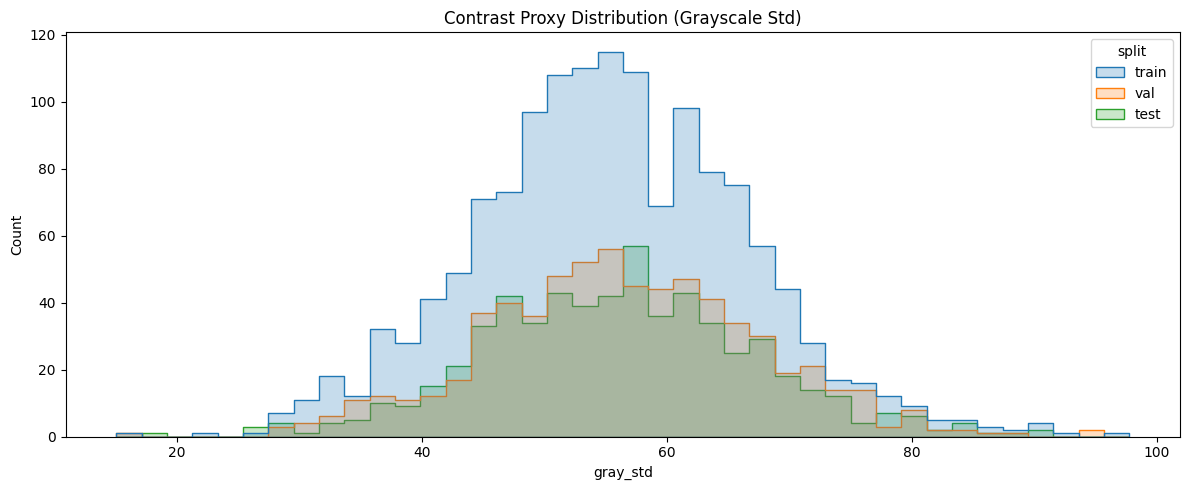

In [ ]:
# Plot contrast distribution across splits
plt.figure(figsize=(12, 5))
sns.histplot(data=gs_df, x="gray_std", hue="split", bins=40, element="step")
plt.title("Contrast Proxy Distribution (Grayscale Std)")
plt.tight_layout()
plt.show()


In [ ]:
# Estimate dataset mean and std for RGB channels from a random sample of training images
def est_rgb_norm(img_pths, cap=1500, tgt_sz=(224, 224), seed=7):
    """Estimate RGB mean and std using a sample of images scaled to [0, 1]."""
    rng = np.random.default_rng(seed)
    use_pths = img_pths[:]
    if len(use_pths) > cap:
        use_pths = list(rng.choice(use_pths, size=cap, replace=False))
    px_sum = np.zeros(3, dtype="float64")
    px_sq = np.zeros(3, dtype="float64")
    px_cnt = 0
    for pth in use_pths:
        try:
            with Image.open(pth) as im:
                im = im.convert("RGB")
                im = im.resize(tgt_sz)
                arr = np.asarray(im).astype("float32") / 255.0
            flat = arr.reshape(-1, 3)
            px_sum += flat.sum(axis=0)
            px_sq += (flat ** 2).sum(axis=0)
            px_cnt += flat.shape[0]
        except Exception:
            pass
    mean = px_sum / max(px_cnt, 1)
    var = (px_sq / max(px_cnt, 1)) - (mean ** 2)
    std = np.sqrt(np.maximum(var, 1e-12))
    return mean, std

rgb_mean, rgb_std = est_rgb_norm(tr_pths, cap=1500, tgt_sz=(224, 224), seed=7)
print("Estimated RGB mean:", rgb_mean)
print("Estimated RGB std :", rgb_std)


Estimated RGB mean: [0.48339286 0.43227058 0.36715964]
Estimated RGB std : [0.25891046 0.25124113 0.25639857]


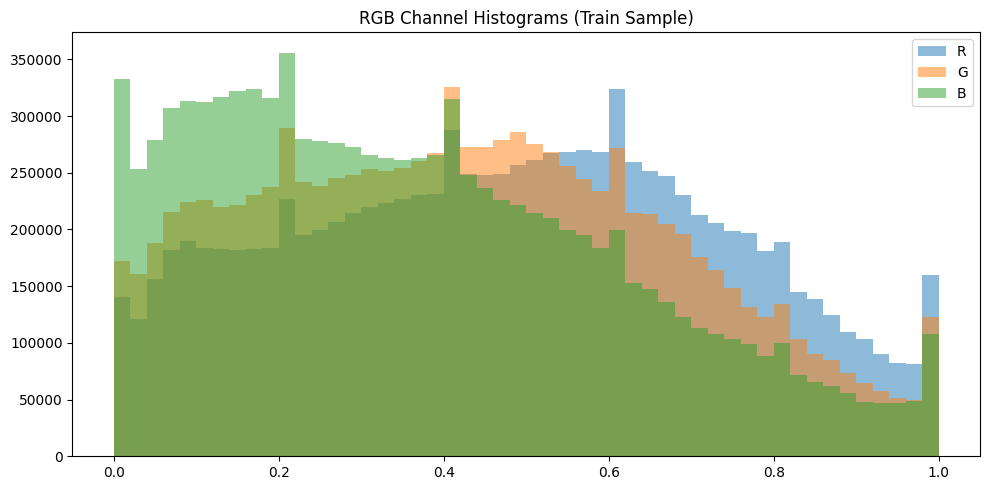

In [ ]:
# Visualize RGB channel histograms from a small sample of training images
def plot_rgb_hists(img_pths, cap=200, tgt_sz=(224, 224), seed=11):
    """Plot RGB histograms from a sampled subset of images in [0, 1] scale."""
    rng = np.random.default_rng(seed)
    use_pths = img_pths[:]
    if len(use_pths) > cap:
        use_pths = list(rng.choice(use_pths, size=cap, replace=False))
    ch_vals = {"r": [], "g": [], "b": []}
    for pth in use_pths:
        try:
            with Image.open(pth) as im:
                im = im.convert("RGB")
                im = im.resize(tgt_sz)
                arr = np.asarray(im).astype("float32") / 255.0
            ch_vals["r"].append(arr[:, :, 0].ravel())
            ch_vals["g"].append(arr[:, :, 1].ravel())
            ch_vals["b"].append(arr[:, :, 2].ravel())
        except Exception:
            pass
    r = np.concatenate(ch_vals["r"]) if len(ch_vals["r"]) else np.array([])
    g = np.concatenate(ch_vals["g"]) if len(ch_vals["g"]) else np.array([])
    b = np.concatenate(ch_vals["b"]) if len(ch_vals["b"]) else np.array([])
    plt.figure(figsize=(10, 5))
    plt.hist(r, bins=50, alpha=0.5, label="R")
    plt.hist(g, bins=50, alpha=0.5, label="G")
    plt.hist(b, bins=50, alpha=0.5, label="B")
    plt.title("RGB Channel Histograms (Train Sample)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_rgb_hists(tr_pths, cap=200, tgt_sz=(224, 224), seed=11)


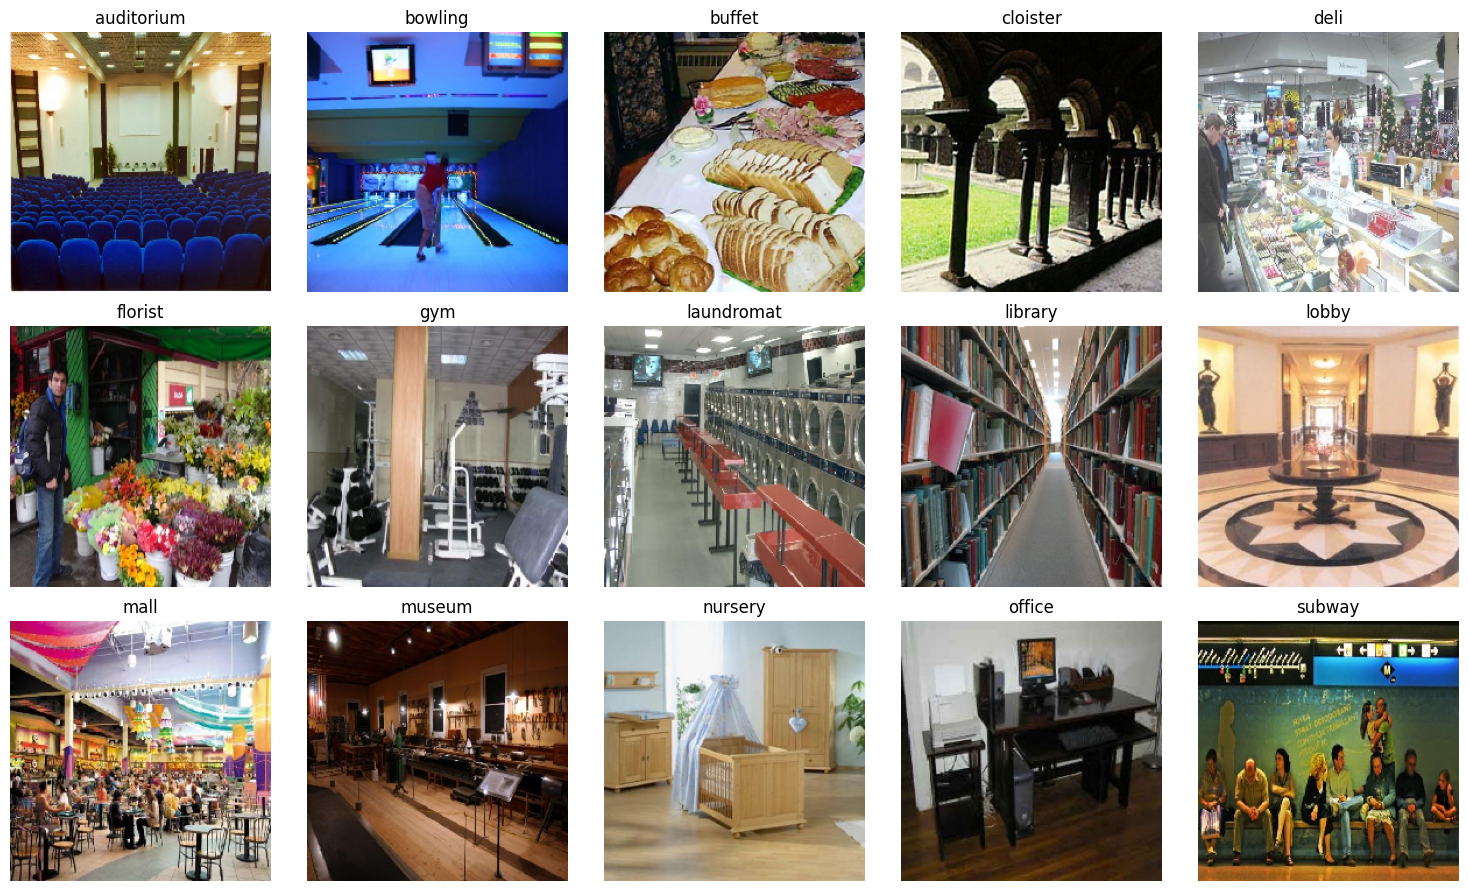

In [ ]:
# Display per-class random samples in a 3x5 grid to sanity-check visual variety
def show_cls_grid(root_dir, grid_r=3, grid_c=5, seed=21, tgt_sz=(224, 224)):
    """Show one random image per class in a fixed grid from root_dir."""
    rng = np.random.default_rng(seed)
    cls_list = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    use_cls = cls_list[: grid_r * grid_c]
    plt.figure(figsize=(15, 9))
    for idx, cls in enumerate(use_cls):
        cls_dir = os.path.join(root_dir, cls)
        img_fns = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        if len(img_fns) > 0:
            pick_fn = img_fns[int(rng.integers(0, len(img_fns)))]
            img_pth = os.path.join(cls_dir, pick_fn)
            img = image.load_img(img_pth, target_size=tgt_sz)
            plt.subplot(grid_r, grid_c, idx + 1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")
    plt.tight_layout()
    plt.show()

show_cls_grid(eda_tr_dir, grid_r=3, grid_c=5, seed=21, tgt_sz=(224, 224))


In [ ]:
# Preview augmentation effects by showing original vs augmented samples for a single class
def show_aug_preview(root_dir, cls_nm, aug_gen, n_show=5, tgt_sz=(224, 224), seed=33):
    """Display original and augmented versions side-by-side for n_show images from one class."""
    rng = np.random.default_rng(seed)
    cls_dir = os.path.join(root_dir, cls_nm)
    img_fns = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if len(img_fns) == 0:
        print("No images found for class:", cls_nm)
        return
    pick_fns = list(rng.choice(img_fns, size=min(n_show, len(img_fns)), replace=False))
    plt.figure(figsize=(12, 2.5 * len(pick_fns)))
    for i, fn in enumerate(pick_fns):
        img_pth = os.path.join(cls_dir, fn)
        pil_img = image.load_img(img_pth, target_size=tgt_sz)
        arr = image.img_to_array(pil_img)
        arr_b = np.expand_dims(arr, axis=0)
        aug_it = aug_gen.flow(arr_b, batch_size=1, shuffle=False)
        aug_arr = next(aug_it)[0].astype("uint8")
        plt.subplot(len(pick_fns), 2, (2 * i) + 1)
        plt.imshow(pil_img)
        plt.title("Original")
        plt.axis("off")
        plt.subplot(len(pick_fns), 2, (2 * i) + 2)
        plt.imshow(aug_arr)
        plt.title("Augmented")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

aug_prev_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)


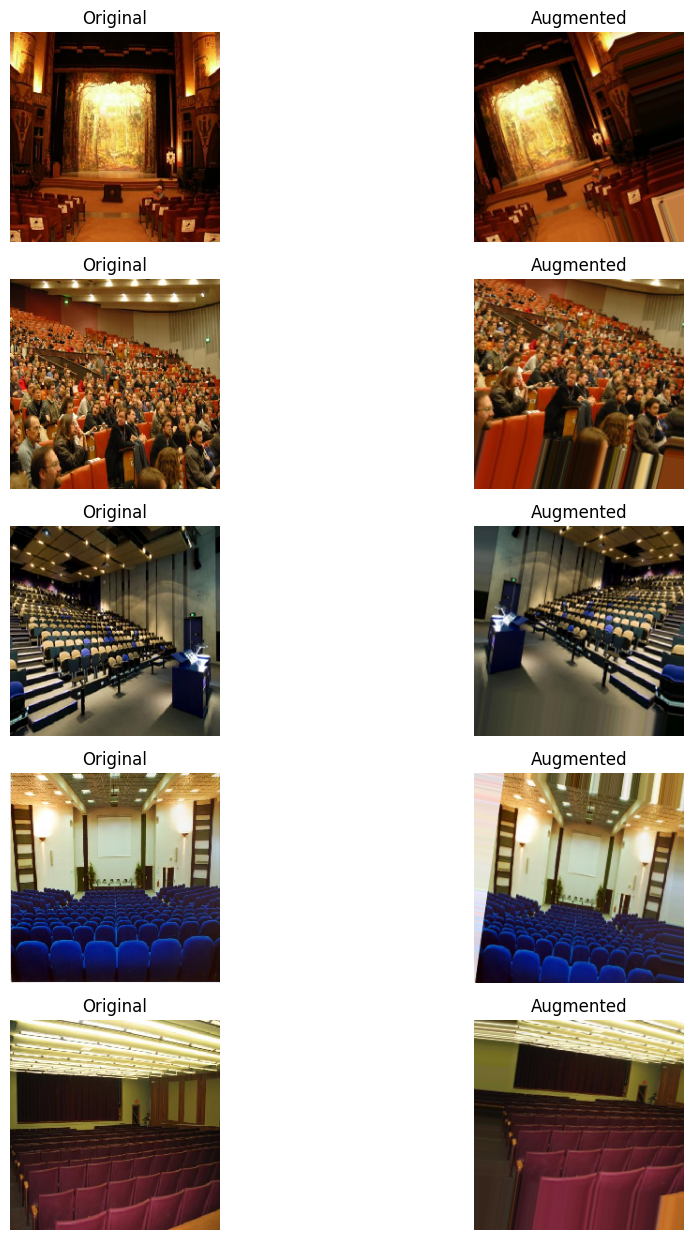

In [ ]:
# Run augmentation preview for a chosen class name from your dataset
pick_cls = "auditorium"
show_aug_preview(eda_tr_dir, pick_cls, aug_prev_gen, n_show=5, tgt_sz=(224, 224), seed=24000105)
